In [50]:
import json
import networkx as nx
from pyvis.network import Network
import community as community_louvain
import matplotlib.cm as cm
from networkx.drawing.nx_agraph import graphviz_layout
from collections import Counter

# === Load graph from JSON ===
with open("abigail_mutuals_graph.json") as f:
    adj_dict = json.load(f)

# === Build directed graph ===
G = nx.DiGraph()
all_nodes = set(adj_dict.keys()) | {v for neighbors in adj_dict.values() for v in neighbors}
G.add_nodes_from(all_nodes)
for u, neighbors in adj_dict.items():
    for v in neighbors:
        G.add_edge(u, v)

# === Identify mutual follows
mutual_pairs = {tuple(sorted((u, v))) for u, v in G.edges() if G.has_edge(v, u)}

# === Community detection
G_undirected = G.to_undirected()
partition = community_louvain.best_partition(G_undirected)
num_communities = len(set(partition.values()))
nx.set_node_attributes(G, partition, "community")

# === Compute node-level stats
clustering = nx.clustering(G_undirected)
in_deg = dict(G.in_degree())
out_deg = dict(G.out_degree())

# === Color mapping per community
color_map = cm.get_cmap("tab20", num_communities)
def community_to_hex(comm_id):
    rgba = color_map(comm_id % color_map.N)
    return '#%02x%02x%02x' % (int(rgba[0]*255), int(rgba[1]*255), int(rgba[2]*255))

# === Get fixed node positions from Graphviz
positions = graphviz_layout(G, prog="sfdp")

# === Initialize PyVis network with physics turned off
nt = Network(height="900px", width="100%", directed=True, notebook=False)
nt.set_options("""
{
  "physics": { "enabled": false },
  "interaction": {
    "hover": true,
    "navigationButtons": true,
    "keyboard": true,
    "multiselect": true,
    "tooltipDelay": 100
  },
  "nodes": {
    "shape": "dot",
    "size": 20,
    "font": { "size": 14, "face": "arial" },
    "borderWidth": 2,
    "borderWidthSelected": 6,
    "color": {
      "border": "#2B7CE9",
      "background": "#97C2FC",
      "highlight": { "border": "#FF0000", "background": "#FFEE88" },
      "hover": { "border": "#FFA500", "background": "#FFFFCC" }
    },
    "chosen": true
  },
  "edges": {
    "color": {
      "color": "#000000",
      "highlight": "#FF0000",
      "hover": "#FF9900",
      "inherit": false
    },
    "width": 1,
    "hoverWidth": 4,
    "selectionWidth": 40,
    "smooth": { "enabled": false }
  }
}
""")

# === Add nodes with fixed positions and hover tooltips
SCALE = 15
for node in G.nodes():
    comm_id = partition[node]
    color = community_to_hex(comm_id)
    x = positions[node][0]*SCALE
    y = positions[node][1]*SCALE
    tooltip = (
        f"{node},"
        f"Community: {comm_id}, "
        f"In-Degree: {in_deg.get(node, 0)}, "
        f"Out-Degree: {out_deg.get(node, 0)}, "
        f"Clustering: {clustering.get(node):.3f}"
    )
    nt.add_node(
        node,
        label=node,
        title=tooltip,
        color=color,
        x=x,
        y=y,
        fixed=True,
        group=str(comm_id),
        data={"group": str(comm_id)}
    )

# === Add edges
for u, v in G.edges():
    pair = tuple(sorted((u, v)))
    if pair in mutual_pairs:
        nt.add_edge(u, v, color='gray', width=1, arrows="")
    else:
        nt.add_edge(u, v, color='green', width=1, arrows='to')

# === Count community sizes
comm_sizes = Counter(partition.values())

# === Write to HTML with community filters
def write_pyvis_with_filters(net, path, comm_sizes):
    net.write_html(path, open_browser=False)

    with open(path, 'r') as f:
        html = f.read()

    # === Sidebar HTML for community checkboxes
    checkbox_html = """
<div style="display: flex; height: 100vh;">
  <div style="width: 250px; padding: 10px; overflow-y: auto; border-right: 1px solid #ccc;">
    <b>Filter by Community:</b><br>
    <button id="toggleAll" style="margin: 5px 0;">Select None</button><br>
"""
    for comm, size in sorted(comm_sizes.items()):
        checkbox_html += f"""
    <label>
      <input type="checkbox" class="communityCheckbox" value="{comm}" checked>
      Community {comm} ({size} Nodes)
    </label><br>
"""
    checkbox_html += "</div>\n<div id='graph-container' style='flex-grow: 1;'>"

    # === Wrap the network canvas with a container div
    html = html.replace('<body>', f'<body>{checkbox_html}')
    html = html.replace('</body>', '</div></div></body>')

    # === JavaScript for checkbox filtering
    script = """
<script type="text/javascript">
document.addEventListener("DOMContentLoaded", function () {
    setTimeout(function () {
        const allNodes = network.body.data.nodes.get();
        const allEdges = network.body.data.edges.get();

        const originalNodes = [...allNodes];
        const originalEdges = [...allEdges];

        function updateCommunityFilter() {
            const checked = Array.from(document.querySelectorAll('.communityCheckbox:checked')).map(cb => cb.value);
            const filteredNodes = originalNodes.filter(n => checked.includes(n.group.toString()));
            const nodeIds = filteredNodes.map(n => n.id);
            const filteredEdges = originalEdges.filter(e => nodeIds.includes(e.from) && nodeIds.includes(e.to));
            network.setData({
                nodes: new vis.DataSet(filteredNodes),
                edges: new vis.DataSet(filteredEdges)
            });
        }

        document.querySelectorAll('.communityCheckbox').forEach(cb => {
            cb.addEventListener('change', updateCommunityFilter);
        });

        document.getElementById("toggleAll").addEventListener("click", function () {
            const checkboxes = document.querySelectorAll('.communityCheckbox');
            const allChecked = Array.from(checkboxes).every(cb => cb.checked);
            checkboxes.forEach(cb => cb.checked = !allChecked);
            this.innerText = allChecked ? "Select All" : "Select None";
            updateCommunityFilter();
        });
    }, 500);
});
</script>
"""
    html = html.replace('</body>', script + '</body>')

    with open(path, 'w') as f:
        f.write(html)

# === Write final HTML
write_pyvis_with_filters(nt, "mutuals_graph_pyvis.html", comm_sizes)


/var/folders/8k/klzglr3x2jl86hl862ddgsm00000gn/T/ipykernel_57006/1324415899.py:36: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  color_map = cm.get_cmap("tab20", num_communities)


In [51]:
import networkx as nx
import numpy as np
import pandas as pd

# Basic Graph Analysis

# Number of nodes and edges
num_nodes = G.number_of_nodes()
num_edges = G.number_of_edges()

# In-degree and out-degree
in_degrees = [deg for _, deg in G.in_degree()]
out_degrees = [deg for _, deg in G.out_degree()]

avg_in_degree = np.mean(in_degrees)
avg_out_degree = np.mean(out_degrees)
max_in_degree = np.max(in_degrees)
max_out_degree = np.max(out_degrees)
min_in_degree = np.min(in_degrees)
min_out_degree = np.min(out_degrees)

# Weakly connected components
num_connected_components = nx.number_weakly_connected_components(G)
largest_cc = max(nx.weakly_connected_components(G), key=len)
subgraph_largest_cc = G.subgraph(largest_cc)

# Display results
print(f"Number of nodes: {num_nodes}")
print(f"Number of edges: {num_edges}")
print(f"Average in-degree: {avg_in_degree:.2f}")
print(f"Average out-degree: {avg_out_degree:.2f}")
print(f"Max in-degree: {max_in_degree}, Min in-degree: {min_in_degree}")
print(f"Max out-degree: {max_out_degree}, Min out-degree: {min_out_degree}")
print(f"Number of weakly connected components: {num_connected_components}")
print(f"Size of largest connected component: {len(largest_cc)}")


Number of nodes: 287
Number of edges: 5853
Average in-degree: 20.39
Average out-degree: 20.39
Max in-degree: 70, Min in-degree: 0
Max out-degree: 88, Min out-degree: 0
Number of weakly connected components: 4
Size of largest connected component: 283


In [52]:
import networkx as nx
from torch_geometric.utils import to_networkx


# Compute in-degrees and out-degrees
in_degrees = dict(G.in_degree())
out_degrees = dict(G.out_degree())
total_degrees = {node: in_degrees[node] + out_degrees[node] for node in G.nodes()}
# Sort by total degree
top_total = sorted(total_degrees.items(), key=lambda x: x[1], reverse=True)


print("Top 10 nodes by total-degree:")
for node, deg in top_total[:10]:
    print(f"Node {node}: {in_degrees[node]} incoming edges and {out_degrees[node]} outgoing edges")

print("\nBottom 10 nodes by total-degree:")
for node, deg in top_total[-1:-11:-1]:
    print(f"Node {node}: {in_degrees[node]} incoming edges and {out_degrees[node]} outgoing edges")






Top 10 nodes by total-degree:
Node gaboffthewall: 62 incoming edges and 87 outgoing edges
Node chloechloenk: 58 incoming edges and 88 outgoing edges
Node owen.pazderak: 70 incoming edges and 74 outgoing edges
Node caroline_stiller541: 62 incoming edges and 81 outgoing edges
Node holly.gumballs: 62 incoming edges and 79 outgoing edges
Node lln.syrs: 59 incoming edges and 76 outgoing edges
Node hnelae: 63 incoming edges and 69 outgoing edges
Node pinkmadigan: 58 incoming edges and 72 outgoing edges
Node sj0850: 49 incoming edges and 78 outgoing edges
Node olivia_kiskadden_: 58 incoming edges and 66 outgoing edges

Bottom 10 nodes by total-degree:
Node aryankotwani9: 0 incoming edges and 0 outgoing edges
Node tessla93: 0 incoming edges and 0 outgoing edges
Node carli_is_actually_trying: 1 incoming edges and 0 outgoing edges
Node very.tired.jezebel: 1 incoming edges and 1 outgoing edges
Node thekarozee: 1 incoming edges and 1 outgoing edges
Node zw_huang99: 0 incoming edges and 2 outgoing 

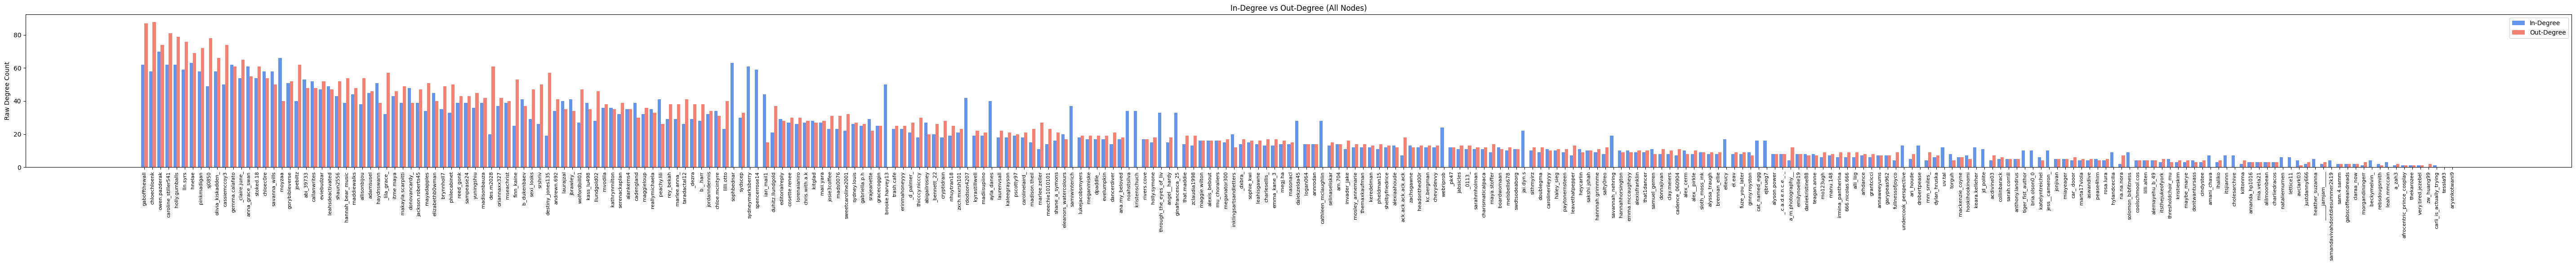

In [53]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Compute raw degree counts
in_degrees = dict(G.in_degree())
out_degrees = dict(G.out_degree())
total_degrees = {node: in_degrees.get(node, 0) + out_degrees.get(node, 0) for node in G.nodes()}

# Create DataFrame
degree_df = pd.DataFrame({
    "in_degree": pd.Series(in_degrees),
    "out_degree": pd.Series(out_degrees),
    "total_degree": pd.Series(total_degrees)
})

# Sort by total degree
degree_df = degree_df.sort_values("total_degree", ascending=False)

# Plot
x = np.arange(len(degree_df))
width = 0.4

plt.figure(figsize=(max(12, len(degree_df) * 0.2), 6))
plt.bar(x - width/2, degree_df["in_degree"], width, label="In-Degree", color="cornflowerblue")
plt.bar(x + width/2, degree_df["out_degree"], width, label="Out-Degree", color="salmon")

plt.xticks(x, degree_df.index, rotation=90, fontsize=8)
plt.ylabel("Raw Degree Count")
plt.title("In-Degree vs Out-Degree (All Nodes)")
plt.legend()
plt.tight_layout()
plt.show()


In [54]:
import pandas as pd
import networkx as nx
import community as community_louvain

# === Compute metrics ===
UG = G.to_undirected()
metrics = {
    "degree_centrality": nx.degree_centrality(G),
    "in_degree_centrality": nx.in_degree_centrality(G),
    "out_degree_centrality": nx.out_degree_centrality(G),
    "closeness_centrality": nx.closeness_centrality(G),
    "betweenness_centrality": nx.betweenness_centrality(G),
    "pagerank": nx.pagerank(G),
    "load_centrality": nx.load_centrality(G),
    "hits_hub": nx.hits(G)[0],
    "hits_auth": nx.hits(G)[1],
    "clustering": nx.clustering(UG),
    "triangles": nx.triangles(UG)
}

# Optional metrics
try:
    metrics["eigenvector_centrality"] = nx.eigenvector_centrality(G, max_iter=1000)
except:
    metrics["eigenvector_centrality"] = None

try:
    metrics["square_clustering"] = nx.square_clustering(UG)
except:
    metrics["square_clustering"] = None

# === Build DataFrame ===
df = pd.DataFrame({k: v for k, v in metrics.items() if isinstance(v, dict)})

# === Add community ID ===
partition = community_louvain.best_partition(UG)
df["community"] = pd.Series(partition)

# === Export CSV ===
df.to_csv("node_metrics_with_community.csv", index_label="username")

# === Build ASCII bar chart leaderboard ===
def ascii_bar(score, min_val, max_val, width=10):
    if max_val == min_val:
        return '-' * width
    norm = (score - min_val) / (max_val - min_val)
    bars = int(norm * width)
    return '#' * bars + '-' * (width - bars)

ascii_leaderboard = pd.DataFrame()

for col in df.columns:
    if col == "community":
        continue
    sorted_col = df[col].sort_values(ascending=False)
    min_val, max_val = sorted_col.min(), sorted_col.max()

    ascii_formatted = [
        f"{idx}: {val:.4f} [{ascii_bar(val, min_val, max_val)}]"
        for idx, val in sorted_col.items()
    ]

    ascii_leaderboard[col] = ascii_formatted

# === Print result ===
print("\nFull ASCII Leaderboard (Sorted Columns):")
print(ascii_leaderboard.to_string(index=False))



Full ASCII Leaderboard (Sorted Columns):
                                 degree_centrality                               in_degree_centrality                              out_degree_centrality                               closeness_centrality                             betweenness_centrality                                           pagerank                                    load_centrality                                            hits_hub                                          hits_auth                                         clustering                                          triangles                             eigenvector_centrality                                  square_clustering
                gaboffthewall: 0.5210 [##########]                 owen.pazderak: 0.2448 [##########]                  chloechloenk: 0.3077 [##########]                    kass_lu498: 0.4162 [##########]                    sampease24: 0.2142 [##########]                    sampease24: 0.0155 [

In [55]:
import networkx as nx
import numpy as np
import pandas as pd

# === Helpers ===
def largest_weakly_connected_subgraph(G):
    wccs = list(nx.weakly_connected_components(G))
    largest_wcc = max(wccs, key=len)
    return G.subgraph(largest_wcc).copy()

def largest_strongly_connected_subgraph(G):
    sccs = list(nx.strongly_connected_components(G))
    largest_scc = max(sccs, key=len)
    return G.subgraph(largest_scc).copy()

# === Compute graph-level statistics ===
def compute_graph_stats(G):
    stats = {}
    stats["is_directed"] = G.is_directed()
    stats["number_of_nodes"] = G.number_of_nodes()
    stats["number_of_edges"] = G.number_of_edges()
    stats["density"] = nx.density(G)

    in_degrees = dict(G.in_degree()) if G.is_directed() else {}
    out_degrees = dict(G.out_degree()) if G.is_directed() else {}
    degrees = dict(G.degree())

    stats["avg_in_degree"] = np.mean(list(in_degrees.values())) if in_degrees else None
    stats["avg_out_degree"] = np.mean(list(out_degrees.values())) if out_degrees else None
    stats["avg_total_degree"] = np.mean(list(degrees.values()))
    stats["max_in_degree"] = max(in_degrees.values()) if in_degrees else None
    stats["max_out_degree"] = max(out_degrees.values()) if out_degrees else None

    try:
        stats["average_clustering"] = nx.average_clustering(G.to_undirected())
        stats["transitivity"] = nx.transitivity(G)
        stats["average_neighbor_degree"] = np.mean(list(nx.average_neighbor_degree(G).values()))
    except:
        stats["average_clustering"] = None
        stats["transitivity"] = None
        stats["average_neighbor_degree"] = None

    try:
        stats["reciprocity"] = nx.reciprocity(G) if G.is_directed() else None
    except:
        stats["reciprocity"] = None

    try:
        stats["degree_assortativity"] = nx.degree_assortativity_coefficient(G)
    except:
        stats["degree_assortativity"] = None

    try:
        stats["global_efficiency"] = nx.global_efficiency(G.to_undirected())
    except:
        stats["global_efficiency"] = None

    try:
        stats["num_triangles"] = sum(nx.triangles(G.to_undirected()).values()) // 3
    except:
        stats["num_triangles"] = None

    try:
        if G.is_directed():
            W = G if nx.is_weakly_connected(G) else largest_weakly_connected_subgraph(G)
            S = G if nx.is_strongly_connected(G) else largest_strongly_connected_subgraph(G)
        else:
            W = G if nx.is_connected(G) else G.subgraph(max(nx.connected_components(G), key=len))
            S = W

        stats["diameter"] = nx.diameter(S.to_undirected())
        stats["avg_shortest_path_length"] = nx.average_shortest_path_length(S)
        stats["radius"] = nx.radius(S.to_undirected())
        ecc = nx.eccentricity(S.to_undirected())
        stats["avg_eccentricity"] = np.mean(list(ecc.values()))
    except:
        stats["diameter"] = None
        stats["avg_shortest_path_length"] = None
        stats["radius"] = None
        stats["avg_eccentricity"] = None

    try:
        degree_values = np.array(list(degrees.values()))
        p = degree_values / degree_values.sum()
        stats["degree_entropy"] = -np.sum(p * np.log2(p))
    except:
        stats["degree_entropy"] = None

    try:
        if G.is_directed():
            stats["num_weakly_connected_components"] = nx.number_weakly_connected_components(G)
            stats["num_strongly_connected_components"] = nx.number_strongly_connected_components(G)
        else:
            stats["num_connected_components"] = nx.number_connected_components(G)
    except:
        stats["num_weakly_connected_components"] = None
        stats["num_strongly_connected_components"] = None
        stats["num_connected_components"] = None

    return stats

# === Global and per-community stats ===
global_stats = compute_graph_stats(G)
global_stats["community"] = "ALL"

community_ids = set(nx.get_node_attributes(G, "community").values())
all_stats = [global_stats]

for comm_id in sorted(community_ids):
    nodes = [n for n, d in G.nodes(data=True) if d.get("community") == comm_id]
    G_comm = G.subgraph(nodes).copy()
    stats = compute_graph_stats(G_comm)
    stats["community"] = comm_id
    all_stats.append(stats)

# === Final dataframe ===
df = pd.DataFrame(all_stats)
df = df.set_index("community").T  # Transpose so rows = metrics, columns = communities
df = df.round(4)
print(df)


community                                ALL          0     1     2  \
is_directed                             True       True  True  True   
number_of_nodes                          287         44     2     1   
number_of_edges                         5853        318     2     0   
density                             0.071307   0.168076   1.0   0.0   
avg_in_degree                      20.393728   7.227273   1.0   0.0   
avg_out_degree                     20.393728   7.227273   1.0   0.0   
avg_total_degree                   40.787456  14.454545   2.0   0.0   
max_in_degree                             70         25     1     0   
max_out_degree                            88         27     1     0   
average_clustering                  0.542585   0.727618   0.0   0.0   
transitivity                        0.415105   0.480983   0.0   0.0   
average_neighbor_degree            22.497537  10.206387   1.0   0.0   
reciprocity                         0.731591   0.805031   1.0   NaN   
degree

/var/folders/8k/klzglr3x2jl86hl862ddgsm00000gn/T/ipykernel_57006/4097995714.py:85: RuntimeWarning: divide by zero encountered in log2
  stats["degree_entropy"] = -np.sum(p * np.log2(p))
/var/folders/8k/klzglr3x2jl86hl862ddgsm00000gn/T/ipykernel_57006/4097995714.py:85: RuntimeWarning: invalid value encountered in multiply
  stats["degree_entropy"] = -np.sum(p * np.log2(p))
/Users/samantha/instagram_network_analysis/.venv/lib/python3.11/site-packages/networkx/algorithms/assortativity/correlation.py:302: RuntimeWarning: invalid value encountered in scalar divide
  return float((xy * (M - ab)).sum() / np.sqrt(vara * varb))
/Users/samantha/instagram_network_analysis/.venv/lib/python3.11/site-packages/networkx/algorithms/assortativity/mixing.py:217: RuntimeWarning: invalid value encountered in divide
  a = a / a.sum()
/var/folders/8k/klzglr3x2jl86hl862ddgsm00000gn/T/ipykernel_57006/4097995714.py:84: RuntimeWarning: invalid value encountered in divide
  p = degree_values / degree_values.sum()

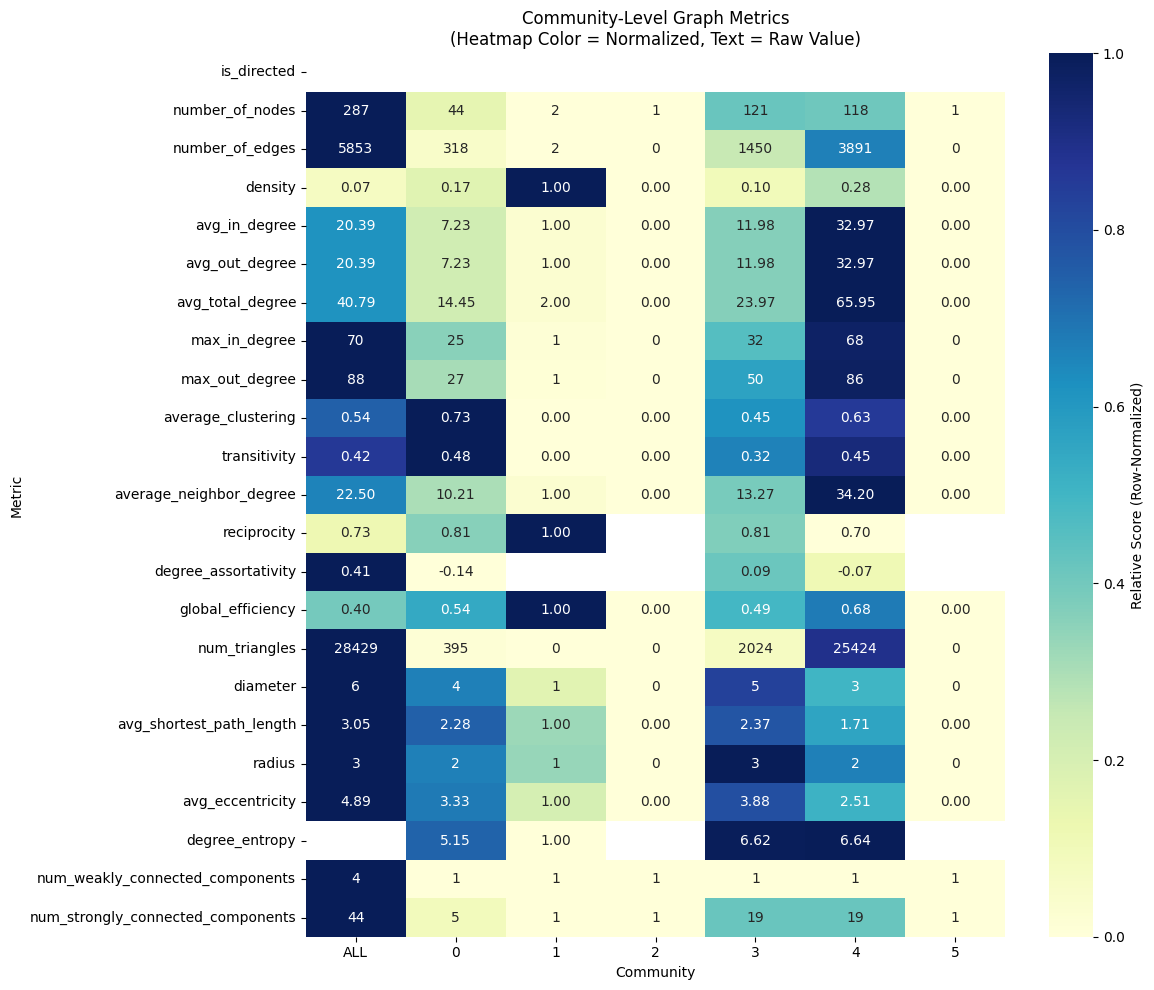

In [56]:
import seaborn as sns
import matplotlib.pyplot as plt

# Ensure numeric and drop non-numeric rows
df_numeric = df.apply(pd.to_numeric, errors='coerce')

# === Normalize by metric (row) for coloring ===
df_colors = df_numeric.subtract(df_numeric.min(axis=1), axis=0)
df_colors = df_colors.divide(df_numeric.max(axis=1) - df_numeric.min(axis=1), axis=0)

# === Format annotations: no decimals for integer-like metrics ===
annot_df = df_numeric.copy().astype(object)

for metric in annot_df.index:
    all_values = annot_df.loc[metric].dropna()
    # If all values are whole numbers, treat as integer-like
    is_integer = all((float(x).is_integer() for x in all_values))
    
    if is_integer:
        annot_df.loc[metric] = annot_df.loc[metric].apply(lambda x: f"{int(x)}" if pd.notna(x) else "")
    else:
        annot_df.loc[metric] = annot_df.loc[metric].apply(lambda x: f"{x:.2f}" if pd.notna(x) else "")

# === Plot heatmap ===
plt.figure(figsize=(12, 10))
sns.heatmap(
    df_colors,
    annot=annot_df,
    fmt="",
    cmap="YlGnBu",
    cbar_kws={'label': 'Relative Score (Row-Normalized)'}
)
plt.title("Community-Level Graph Metrics\n(Heatmap Color = Normalized, Text = Raw Value)")
plt.xlabel("Community")
plt.ylabel("Metric")
plt.tight_layout()
plt.show()
